In [15]:
# Grigorescu Stefan-Dumitru (331)
# Podaru Eduard-Cristian (331)


# - link nbviewer:
#      https://nbviewer.org/
#   
# - link tema 1 deschisa de nbviewer:
#      https://nbviewer.org/urls/cs.unibuc.ro/~pirofti/ps/ps-tema-1.ipynb

import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd


In [16]:
class Signal:
    notes_frequencies_dictionary = {
        "x":   0.0,
       "C0":   16.35,
      "C#0":   17.32,
      "Db0":   17.32,
       "D0":   18.35,
      "D#0":   19.45,
      "Eb0":   19.45,
       "E0":   20.60,
       "F0":   21.83,
      "F#0":   23.12,
      "Gb0":   23.12,
       "G0":   24.50,
      "G#0":   25.96,
      "Ab0":   25.96,
       "A0":   27.50,
      "A#0":   29.14,
      "Bb0":   29.14,
       "B0":   30.87,
       "C1":   32.70,
      "C#1":   34.65,
      "Db1":   34.65,
       "D1":   36.71,
      "D#1":   38.89,
      "Eb1":   38.89,
       "E1":   41.20,
       "F1":   43.65,
      "F#1":   46.25,
      "Gb1":   46.25,
       "G1":   49.00,
      "G#1":   51.91,
      "Ab1":   51.91,
       "A1":   55.00,
      "A#1":   58.27,
      "Bb1":   58.27,
       "B1":   61.74,
       "C2":   65.41,
      "C#2":   69.30,
      "Db2":   69.30,
       "D2":   73.42,
      "D#2":   77.78,
      "Eb2":   77.78,
       "E2":   82.41,
       "F2":   87.31,
      "F#2":   92.50,
      "Gb2":   92.50,
       "G2":   98.00,
      "G#2":  103.83,
      "Ab2":  103.83,
       "A2":  110.00,
      "A#2":  116.54,
      "Bb2":  116.54,
       "B2":  123.47,
       "C3":  130.81,
      "C#3":  138.59,
      "Db3":  138.59,
       "D3":  146.83,
      "D#3":  155.56,
      "Eb3":  155.56,
       "E3":  164.81,
       "F3":  174.61,
      "F#3":  185.00,
      "Gb3":  185.00,
       "G3":  196.00,
      "G#3":  207.65,
      "Ab3":  207.65,
       "A3":  220.00,
      "A#3":  233.08,
      "Bb3":  233.08,
       "B3":  246.94,
       "C4":  261.63,
      "C#4":  277.18,
      "Db4":  277.18,
       "D4":  293.66,
      "D#4":  311.13,
      "Eb4":  311.13,
       "E4":  329.63,
       "F4":  349.23,
      "F#4":  369.99,
      "Gb4":  369.99,
       "G4":  392.00,
      "G#4":  415.30,
      "Ab4":  415.30,
       "A4":  440.00,
      "A#4":  466.16,
      "Bb4":  466.16,
       "B4":  493.88,
       "C5":  523.25,
      "C#5":  554.37,
      "Db5":  554.37,
       "D5":  587.33,
      "D#5":  622.25,
      "Eb5":  622.25,
       "E5":  659.26,
       "F5":  698.46,
      "F#5":  739.99,
      "Gb5":  739.99,
       "G5":  783.99,
      "G#5":  830.61,
      "Ab5":  830.61,
       "A5":  880.00,
      "A#5":  932.33,
      "Bb5":  932.33,
       "B5":  987.77,
       "C6": 1046.50,
      "C#6": 1108.73,
      "Db6": 1108.73,
       "D6": 1174.66,
      "D#6": 1244.51,
      "Eb6": 1244.51,
       "E6": 1318.51,
       "F6": 1396.91,
      "F#6": 1479.98,
      "Gb6": 1479.98,
       "G6": 1567.98,
      "G#6": 1661.22,
      "Ab6": 1661.22,
       "A6": 1760.00,
      "A#6": 1864.66,
      "Bb6": 1864.66,
       "B6": 1975.53,
       "C7": 2093.00,
      "C#7": 2217.46,
      "Db7": 2217.46,
       "D7": 2349.32,
      "D#7": 2489.02,
      "Eb7": 2489.02,
       "E7": 2637.02,
       "F7": 2793.83,
      "F#7": 2959.96,
      "Gb7": 2959.96,
       "G7": 3135.96,
      "G#7": 3322.44,
      "Ab7": 3322.44,
       "A7": 3520.00,
      "A#7": 3729.31,
      "Bb7": 3729.31,
       "B7": 3951.07,
       "C8": 4186.01,
      "C#8": 4434.92,
      "Db8": 4434.92,
       "D8": 4698.64,
      "D#8": 4978.03,
      "Eb8": 4978.03,
       "E8": 5274.04,
       "F8": 5587.65,
      "F#8": 5919.91,
      "Gb8": 5919.91,
       "G8": 6271.93,
      "G#8": 6644.88,
      "Ab8": 6644.88,
       "A8": 7040.00,
      "A#8": 7458.62,
      "Bb8": 7458.62,
       "B8": 7902.13
    }
    bpm = 144                                   # beats per minute
    beats_per_second = bpm/60                   # in one second we only have 1/60 of the beats we had in one minute 
    full_notes_per_second = beats_per_second/4  # one full note = 4 beats
    
    def __init__(self, time_of_view = 1, frequency = 440, amplitude = 1e4, phase = 0, sampling_rate = 441e2):
        self.time_of_view = time_of_view                          # seconds
        self.frequency = frequency                                # Hertz
        self.amplitude = amplitude                                # meters
        self.phase = phase                                        # radians
        
        self.sampling_rate = sampling_rate                        # Hertz
        self.sampling_period = 1./self.sampling_rate              # seconds
        self.n_samples = self.time_of_view/self.sampling_period   # no unit of measure 
        
        self.atime = np.linspace (0, self.time_of_view, int(10e5 + 1))           # seconds
        self.time = np.linspace (0, self.time_of_view, int(self.n_samples + 1))  # seconds
        
        self.asignal = self.sine(self.amplitude, self.frequency, self.atime, self.phase)
        self.signal = self.sine(self.amplitude, self.frequency, self.time, self.phase)
        
    def plot(self):
        plt.grid(True)
        plt.plot(self.atime, self.asignal)
        
    def stem(self):
        plt.grid(True)
        plt.stem (self.time, self.signal)
    
    def play(self):  
        sd.default.samplerate = self.sampling_rate
        wav_wave = np.array(self.signal, dtype=np.int16)
        sd.play(wav_wave, blocking=True)
        sd.stop()
        
    @classmethod
    def sine (cls, amplitude, frequency, time, phase):
        return float(amplitude) * np.sin (2.0 * np.pi * frequency * time + float(phase))
    
    @classmethod
    def get_time_of_view(cls, musical_duration):
        # print(musical_duration)
        return musical_duration/cls.full_notes_per_second
    
    @staticmethod
    def playSignal(signal, sampling_rate = 441e2):
        sd.default.samplerate = sampling_rate
        wav_wave = np.array(signal, dtype=np.int16)
        sd.play(wav_wave, blocking=True)
        sd.stop()

    @staticmethod
    def create_song_signal(notes):
        song_signal = np.asarray([])

        for (note, musical_duration) in notes:
            note_frequency = Signal.notes_frequencies_dictionary[note]
            time_of_view = Signal.get_time_of_view(musical_duration)
            
            note_signal = Signal(time_of_view, note_frequency).signal
            song_signal = np.concatenate((song_signal, note_signal))
        
        return song_signal

    @staticmethod
    def read_song():
        number_of_notes = int(input("Song creation\nNumber of notes="))

        notes = []
        print("Enter each note and their duration on separate lines(i.e. E0 1/4)\n")
        for _ in range(number_of_notes):
            input_str = input()
            split = input_str.split(' ')
            note = (split[0], eval(split[1]))
            notes.append(note)

        return notes
    
    
musical_notes_as_signals = {name: Signal(1, frequency)  for (name, frequency) in Signal.notes_frequencies_dictionary.items()}


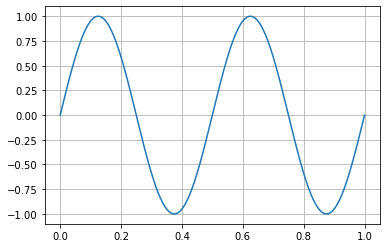

In [3]:
signalExp = Signal(1, 2, 1, 0, 12)

signalExp.plot()


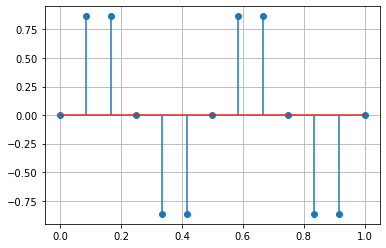

In [4]:
signalExp.stem()


In [5]:
# # uncomment to play

# signalExp1 = Signal()
# signalExp1.play()


In [6]:
# uncomment to play

# for (name, signal) in Signal.musical_notes_as_signals.items():
#     signal.play()
    

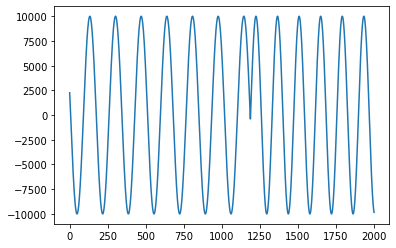

In [14]:
# https://tabs.ultimate-guitar.com/tab/nirvana/smells-like-teen-spirit-tabs-202725
# https://musescore.com/user/1903911/scores/1783286

smells_like_teen_spirit_notes_and_length = [("C4", 1/8), ("Eb4", 1/4), ("G4", 1/4), ("G#3", 3/8), ("x", 1/8), ("Eb4", 1/8), ("F4", 1/8), ("Eb4", 1/8), ("C#4", 1/8), ("C4", 3/8), ("C4", 1/8), ("C#4", 3/8), ("G#3", 1/8), ("F#3", 3/8)]
smells_like_teen_spirit_notes_and_length += smells_like_teen_spirit_notes_and_length
smells_like_teen_spirit_notes_and_length += 5 * [("G#4", 1/8), ("G4", 3/8), ("G#4", 1/8), ("G4", 3/8), ("G#4", 1/8), ("G4", 1/4), ("G4", 1/8), ("F4", 1/4)]
smells_like_teen_spirit_notes_and_length += [("G#4", 1/8), ("G4", 3/8), ("G#4", 1/8), ("G4", 3/8), ("G#4", 1/8), ("G4", 1/4), ("G4", 1/8), ("F4", 17/4)]

song_signal = Signal.create_song_signal(smells_like_teen_spirit_notes_and_length)
# Signal.playSignal(song_signal)
plt.plot( song_signal[8000:10000])
plt.show()

In [8]:
song_signal = Signal.create_song_signal(Signal.read_song())

Signal.playSignal(song_signal)

KeyboardInterrupt: Interrupted by user

In [ ]:
#  C  D  E  F  G  A  B  C
# do re mi fa sol la si do

doremi = [("C4", 1/2), ("D4", 1/2), ("E4", 1/2), ("F4", 1/2), ("G4", 1/2), ("A4", 1/2), ("B4", 1/2), ("C5", 1/2)]

song_signal = Signal.create_song_signal(doremi)
Signal.playSignal(song_signal)